# Diabetes Predictions

In [1]:
from sklearn.datasets import load_diabetes

In [2]:
dataset = load_diabetes()

In [3]:
print(dataset['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [6]:
import pandas as pd

df_diabetes = pd.DataFrame(dataset.data, columns=['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'])

df_diabetes.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [8]:
## Independent and dependent features

X = df_diabetes
y = dataset['target']

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)

In [11]:
# correlation

X_train.corr()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.197408,0.198359,0.394903,0.238375,0.192920,-0.128403,0.227110,0.314151,0.351570
sex,0.197408,1.000000,0.108261,0.221914,0.057674,0.180315,-0.379464,0.324882,0.150956,0.193322
bmi,0.198359,0.108261,1.000000,0.356324,0.226047,0.248146,-0.395021,0.412826,0.435505,0.358273
bp,0.394903,0.221914,0.356324,1.000000,0.238295,0.165632,-0.192505,0.249141,0.420236,0.368882
s1,0.238375,0.057674,0.226047,0.238295,1.000000,0.872781,0.006313,0.559626,0.566312,0.356280
s2,0.192920,0.180315,0.248146,0.165632,0.872781,1.000000,-0.265114,0.684840,0.325759,0.315890
s3,-0.128403,-0.379464,-0.395021,-0.192505,0.006313,-0.265114,1.000000,-0.754616,-0.370523,-0.297055
s4,0.227110,0.324882,0.412826,0.249141,0.559626,0.684840,-0.754616,1.000000,0.609983,0.436311
s5,0.314151,0.150956,0.435505,0.420236,0.566312,0.325759,-0.370523,0.609983,1.000000,0.490970
s6,0.351570,0.193322,0.358273,0.368882,0.356280,0.315890,-0.297055,0.436311,0.490970,1.000000


<Axes: >

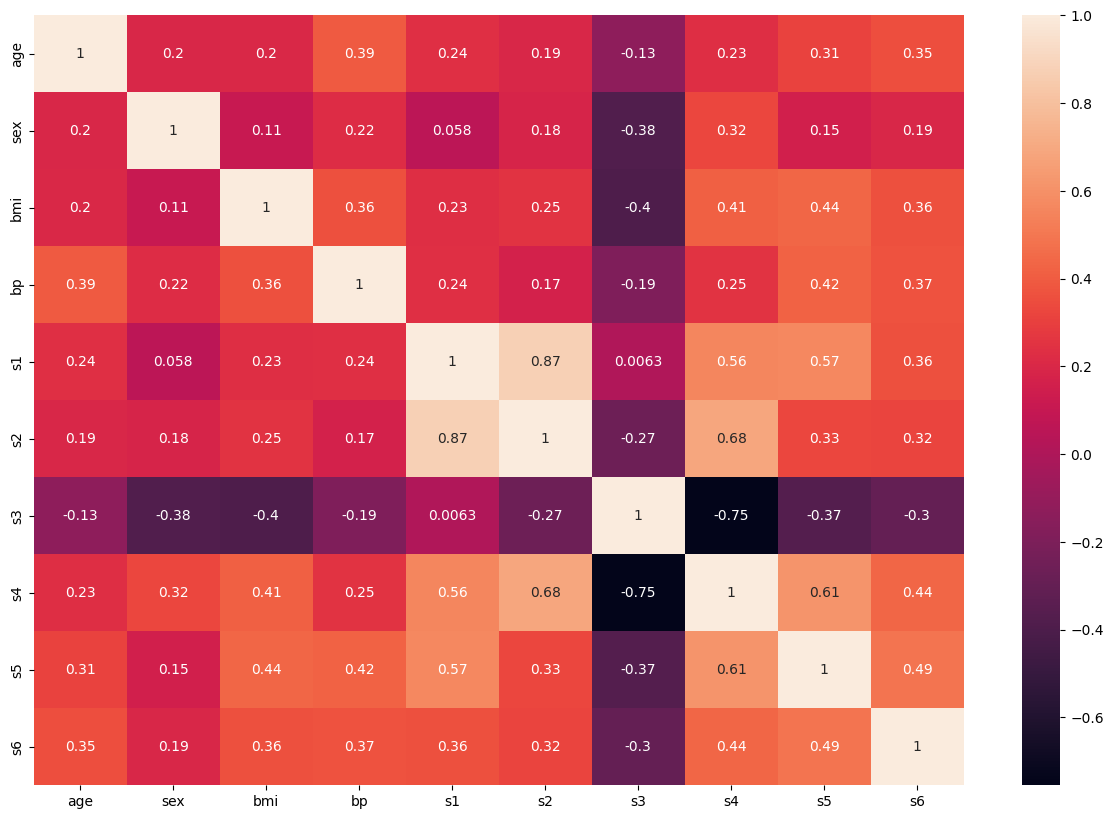

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
sns.heatmap(X_train.corr(), annot=True)

In [13]:
from sklearn.tree import DecisionTreeRegressor

regressor = DecisionTreeRegressor()
regressor.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [21]:
y_pred = regressor.predict(X_test)

In [24]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [25]:
print(f'''
R2 Score: {r2_score(y_test, y_pred)}
Mean Absolute Error: {mean_absolute_error(y_test, y_pred)}
Mean Squared Error: {mean_squared_error(y_test, y_pred)}
''')


R2 Score: -0.17088060633230162
Mean Absolute Error: 67.36842105263158
Mean Squared Error: 7408.9473684210525



## Hyperparameter tuning

In [14]:
params = {
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
    'splitter': ['best', 'random'],
    'max_depth': [1, 2, 3, 4, 5, 10, 15, 20, 25],
    'max_features': ['auto', 'sqrt', 'log2']
}

In [15]:
from sklearn.model_selection import GridSearchCV

In [16]:
grid_regressor = DecisionTreeRegressor()

In [17]:
grid = GridSearchCV(grid_regressor, param_grid=params, cv=5, scoring='neg_mean_squared_error')

In [18]:
import warnings

# Temporarily ignore warnings
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    # Also specifically ignore common sklearn warnings if needed
    warnings.simplefilter("ignore", category=UserWarning)
    
    grid.fit(X_train, y_train)

In [19]:
grid

,estimator,DecisionTreeRegressor()
,param_grid,"{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [1, 2, ...], 'max_features': ['auto', 'sqrt', ...], 'splitter': ['best', 'random']}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'friedman_mse'


In [20]:
grid.best_params_

{'criterion': 'friedman_mse',
 'max_depth': 5,
 'max_features': 'sqrt',
 'splitter': 'random'}

In [22]:
y_pred_grid = grid.predict(X_test)

In [26]:
print(f'''
R2 Score: {r2_score(y_test, y_pred_grid)}
Mean Absolute Error: {mean_absolute_error(y_test, y_pred_grid)}
Mean Squared Error: {mean_squared_error(y_test, y_pred_grid)}
''')


R2 Score: 0.2724817545342838
Mean Absolute Error: 54.37430423216259
Mean Squared Error: 4603.4961729409415



### Visulise the tree

In [27]:
selectedModel = DecisionTreeRegressor(criterion='friedman_mse', max_depth=5, max_features='sqrt', splitter='random')

In [29]:
selectedModel.fit(X_train, y_train)

,criterion,'friedman_mse'
,splitter,'random'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


[Text(0.5387931034482759, 0.9166666666666666, 'x[6] <= -0.008\nfriedman_mse = 5757.456\nsamples = 309\nvalue = 152.738'),
 Text(0.27586206896551724, 0.75, 'x[1] <= 0.049\nfriedman_mse = 5860.499\nsamples = 162\nvalue = 179.883'),
 Text(0.4073275862068966, 0.8333333333333333, 'True  '),
 Text(0.13793103448275862, 0.5833333333333334, 'x[2] <= 0.042\nfriedman_mse = 5400.002\nsamples = 57\nvalue = 193.456'),
 Text(0.06896551724137931, 0.4166666666666667, 'x[4] <= -0.066\nfriedman_mse = 4448.608\nsamples = 36\nvalue = 175.056'),
 Text(0.034482758620689655, 0.25, 'x[8] <= -0.031\nfriedman_mse = 2499.556\nsamples = 3\nvalue = 144.667'),
 Text(0.017241379310344827, 0.08333333333333333, 'friedman_mse = 2704.0\nsamples = 2\nvalue = 126.0'),
 Text(0.05172413793103448, 0.08333333333333333, 'friedman_mse = 0.0\nsamples = 1\nvalue = 182.0'),
 Text(0.10344827586206896, 0.25, 'x[7] <= 0.028\nfriedman_mse = 4534.209\nsamples = 33\nvalue = 177.818'),
 Text(0.08620689655172414, 0.08333333333333333, 'frie

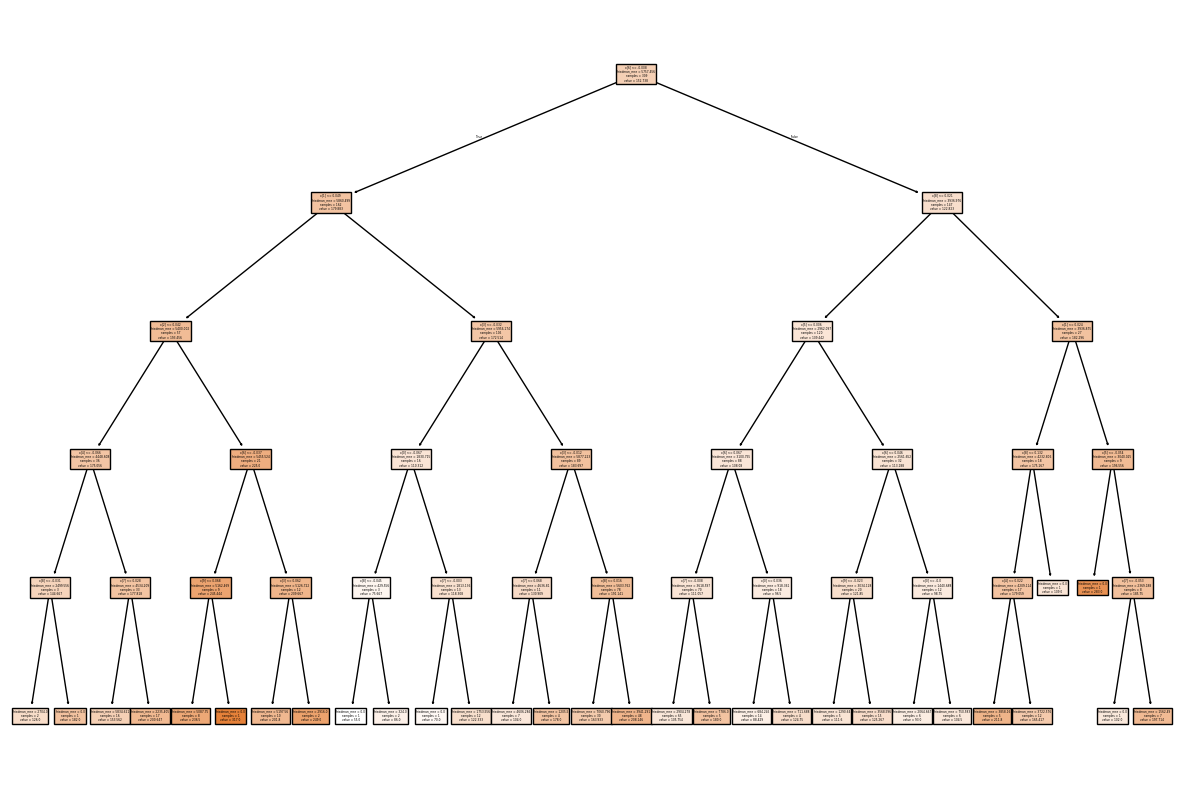

In [30]:
from sklearn import tree

plt.figure(figsize=(15, 10))

tree.plot_tree(selectedModel, filled=True)